In [32]:
import json
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [33]:
# load data
data = json.load(open('train_test_data_without_time_tts.json'))

X_train = data['X_train']
X_test = data['X_test']

X_train = pd.DataFrame(X_train)  
X_test = pd.DataFrame(X_test)

y_train = data['y_train']
y_test = data['y_test']

y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

### `calculate_woe_iv` function

Weight of evidence (WOE) mapping and information value for a given feature.

In [34]:
def calculate_woe_iv(df: pd.DataFrame, feature_col: str, target_col: str, eps: float = 1e-6):
   
    temp = df[[feature_col, target_col]].copy()

    # treat missing bins as a separate category
    temp[feature_col] = temp[feature_col].astype("object").fillna("MISSING")

    grouped = temp.groupby(feature_col, dropna=False)[target_col].agg(["count", "sum"])
    grouped.columns = ["total", "bad"]   # assuming target=1 is bad
    grouped["good"] = grouped["total"] - grouped["bad"]

    total_good = grouped["good"].sum()
    total_bad = grouped["bad"].sum()

    grouped["dist_good"] = grouped["good"] / max(total_good, eps)
    grouped["dist_bad"] = grouped["bad"] / max(total_bad, eps)

    # Avoid log(0)
    grouped["woe"] = np.log((grouped["dist_good"] + eps) / (grouped["dist_bad"] + eps))
    grouped["iv_component"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["woe"]

    woe_map = grouped["woe"].to_dict()
    iv = grouped["iv_component"].sum()

    return woe_map, iv

### Binning numerical features with quantile binning

This code converts continuous numerical variables into quantile-based bins.  
Binning is commonly used in credit scoring pipelines, especially before applying WOE transformations.

In [35]:
X_train = pd.DataFrame(X_train)  
X_test = pd.DataFrame(X_test)

num_cols = [
"loan_amount",
"existing_klarna_debt",
"days_since_first_loan",
"num_active_loans",
"new_exposure_7d",
"new_exposure_14d",
"num_confirmed_payments_3m",
"num_confirmed_payments_6m",
"num_failed_payments_3m",
"num_failed_payments_6m",
"num_failed_payments_1y",
"amount_repaid_14d",
"amount_repaid_1m",
"amount_repaid_3m",
"amount_repaid_6m",
"amount_repaid_1y",
"debt_to_loan_ratio",
"exposure_growth",
"failed_payment_ratio_3m",
"failed_payment_ratio_6m",
"repayment_speed",
"repayment_ratio_6m",
"loan_intensity",
"merchant_default_rate",
"merchant_group_default_rate"
]

for col in num_cols:
    X_train[col + "_bin"] = pd.qcut(X_train[col], q=10, duplicates="drop")
    X_test[col + "_bin"] = pd.qcut(X_test[col], q=10, duplicates="drop")

This code performs quantile binning on numerical variables using only the training data,  
stores the learned bin boundaries, and then applies the same bins to both training and test datasets.  
This approach avoids data leakage and ensures consistent feature transformation.

In [36]:
bin_edges_dict = {}

for col in num_cols:
    
    # learn bins on train only
    _, bin_edges = pd.qcut(
        X_train[col],
        q=10,
        duplicates="drop",
        retbins=True
    )

    # make edges slightly wider to avoid boundary issues
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    bin_edges_dict[col] = bin_edges

    # apply same bins to both train and test
    X_train[col + "_bin"] = pd.cut(X_train[col], bins=bin_edges, include_lowest=True)
    X_test[col + "_bin"] = pd.cut(X_test[col], bins=bin_edges, include_lowest=True)

#### WOE transformation and IV calculation

In [37]:
woe_dict = {}
iv_dict = {}

for col in num_cols:
    bin_col = col + "_bin"

    df_temp = pd.concat([X_train[bin_col], y_train.rename("target")], axis=1)

    woe_map, iv = calculate_woe_iv(df_temp, bin_col, "target")

    woe_dict[col] = woe_map
    iv_dict[col] = iv

    X_train[col + "_woe"] = X_train[bin_col].map(woe_map)
    X_test[col + "_woe"] = X_test[bin_col].map(woe_map)

In [38]:
cols_to_drop = num_cols + [col + "_bin" for col in num_cols]

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

#### IV summary table

In [39]:
iv_df = pd.DataFrame({
    "feature": iv_dict.keys(),
    "IV": iv_dict.values()
}).sort_values("IV", ascending=False)

print(iv_df)

                        feature            IV
21           repayment_ratio_6m  1.274977e-01
15             amount_repaid_1y  1.164163e-01
23        merchant_default_rate  1.111000e-01
7     num_confirmed_payments_6m  1.062807e-01
14             amount_repaid_6m  9.906661e-02
2         days_since_first_loan  8.456436e-02
6     num_confirmed_payments_3m  8.367320e-02
13             amount_repaid_3m  7.499130e-02
20              repayment_speed  6.210456e-02
24  merchant_group_default_rate  4.400200e-02
12             amount_repaid_1m  4.100312e-02
11            amount_repaid_14d  3.306689e-02
22               loan_intensity  2.888289e-02
16           debt_to_loan_ratio  2.195737e-02
0                   loan_amount  1.801995e-02
3              num_active_loans  1.393788e-02
1          existing_klarna_debt  1.332042e-02
5              new_exposure_14d  2.008313e-03
4               new_exposure_7d  6.442762e-09
10       num_failed_payments_1y  0.000000e+00
9        num_failed_payments_6m  0

In [40]:
# features with law predictive power
low_iv_features = iv_df[iv_df["IV"] < 0.01]

print(low_iv_features)

                    feature            IV
5          new_exposure_14d  2.008313e-03
4           new_exposure_7d  6.442762e-09
10   num_failed_payments_1y  0.000000e+00
9    num_failed_payments_6m  0.000000e+00
8    num_failed_payments_3m  0.000000e+00
17          exposure_growth  0.000000e+00
18  failed_payment_ratio_3m  0.000000e+00
19  failed_payment_ratio_6m  0.000000e+00


In [43]:

X_train = X_train.drop(columns=["existing_klarna_debt_woe","new_exposure_14d_woe","loan_intensity_woe","num_failed_payments_1y_woe","num_failed_payments_6m_woe","num_failed_payments_3m_woe","exposure_growth_woe","failed_payment_ratio_3m_woe","failed_payment_ratio_6m_woe","new_exposure_7d_woe"],axis=1)
X_test = X_test.drop(columns=["existing_klarna_debt_woe","new_exposure_14d_woe","loan_intensity_woe","num_failed_payments_1y_woe","num_failed_payments_6m_woe","num_failed_payments_3m_woe","exposure_growth_woe","failed_payment_ratio_3m_woe","failed_payment_ratio_6m_woe","new_exposure_7d_woe"],axis=1)

#### Checking multicollinearity using VIF

This code calculates the VIF for each feature in the training dataset to detect multicollinearity between predictors.

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [45]:
vif_df = pd.DataFrame()
vif_df["feature"] = X_train.columns

vif_df["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

print(vif_df.sort_values("VIF", ascending=False))

                            feature         VIF
3                        loan_month  776.784871
4                         loan_week  744.652372
15             amount_repaid_6m_woe   18.451434
11    num_confirmed_payments_6m_woe   13.145954
19           repayment_ratio_6m_woe   11.507861
14             amount_repaid_3m_woe   10.988671
10    num_confirmed_payments_3m_woe    9.691753
0                   is_new_customer    9.107927
13             amount_repaid_1m_woe    8.620874
18              repayment_speed_woe    7.394426
16             amount_repaid_1y_woe    7.034976
1      existing_klarna_debt_missing    5.178542
12            amount_repaid_14d_woe    4.228308
8         days_since_first_loan_woe    4.100656
2                    loan_dayofweek    3.507388
6               payment_reliability    2.549779
17           debt_to_loan_ratio_woe    2.525439
9              num_active_loans_woe    2.217129
20        merchant_default_rate_woe    1.670778
21  merchant_group_default_rate_woe    1

In [46]:
#Dropping features with high VIF

high_vif_features = vif_df.loc[vif_df["VIF"] > 8, "feature"].tolist()
X_train.drop(columns=high_vif_features, inplace=True, errors="ignore")
X_test.drop(columns=high_vif_features, inplace=True, errors="ignore")
print("dropped high vif features:", high_vif_features)

dropped high vif features: ['is_new_customer', 'loan_month', 'loan_week', 'num_confirmed_payments_3m_woe', 'num_confirmed_payments_6m_woe', 'amount_repaid_1m_woe', 'amount_repaid_3m_woe', 'amount_repaid_6m_woe', 'repayment_ratio_6m_woe']


#### Hyperparameter Tuning for Logistic Regression using GridSearchCV

This code performs hyperparameter tuning for a Logistic Regression model using `GridSearchCV`.  
The goal is to find the combination of parameters that maximizes recall, which is particularly important in credit risk models, where detecting defaulters (bad customers) is critical.

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced", {0: 1, 1: 2}, {0: 1, 1: 3}]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42,solver="lbfgs"),
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV recall:", grid.best_score_)

Best params: {'C': 0.01, 'class_weight': 'balanced'}
Best CV recall: 0.6479184962881062


#### Training the Logistic Regression Model

In [48]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver="lbfgs",
    C=0.01,
)

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :te

In [49]:
y_train_pred_proba = log_model.predict_proba(X_train)[:,1]
y_test_pred_proba = log_model.predict_proba(X_test)[:,1]
y_test_pred = log_model.predict(X_test)

In [50]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

auc_train = roc_auc_score(y_train, y_train_pred_proba)
auc_test = roc_auc_score(y_test, y_test_pred_proba)

print("Train AUC:", auc_train)
print("Test AUC:", auc_test)

print(confusion_matrix(y_test, y_test_pred))

from sklearn.metrics import recall_score

recall = recall_score(y_test, y_test_pred)

print("Recall:", recall)

print(classification_report(y_test, y_test_pred))

Train AUC: 0.6478455060251108
Test AUC: 0.6293766324193728
[[12027  9103]
 [  461   757]]
Recall: 0.6215106732348111
              precision    recall  f1-score   support

           0       0.96      0.57      0.72     21130
           1       0.08      0.62      0.14      1218

    accuracy                           0.57     22348
   macro avg       0.52      0.60      0.43     22348
weighted avg       0.91      0.57      0.68     22348



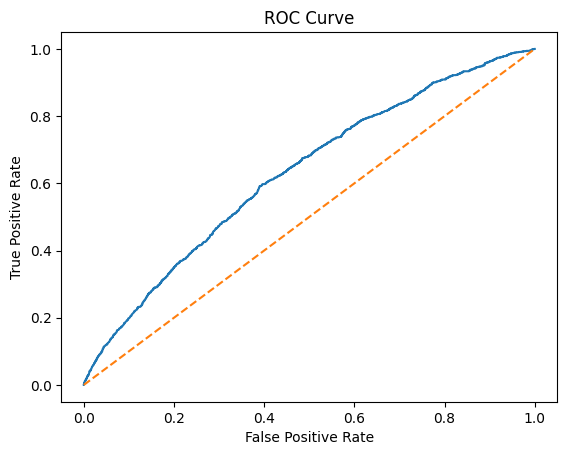

In [51]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [52]:
from scipy.stats import ks_2samp

ks_stat = ks_2samp(
    y_test_pred_proba[y_test == 0],
    y_test_pred_proba[y_test == 1]
)

print("KS Statistic:", ks_stat.statistic)

KS Statistic: 0.20163939394645863


In [319]:
import joblib

joblib.dump(log_model, "logistic_model_with_woe.pkl")

['logistic_model_with_woe.pkl']